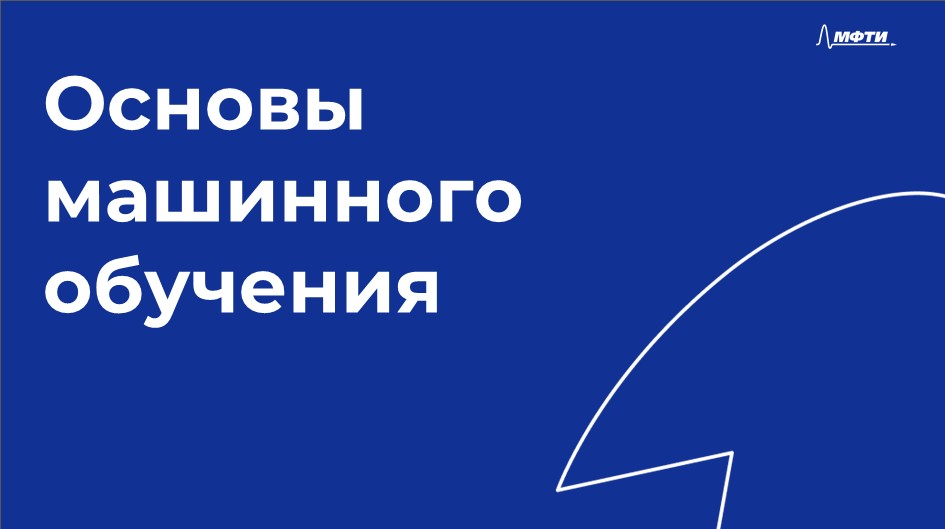

# 🎯 Неделя 2. Семинар 3.

**Сегодня в программе:**
1. Поэкспериментируем с гиперпараметрами классического градиентного спуска и стохастического.
2. Рассмотрим более продвинутые модификации: AdaGrad и Adam.
3. Добавим раннюю остановку.

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# данные, предобработка, моделирование
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# метрики
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    max_error,
    r2_score
)

np.random.seed(28)

## 🟢 1. Поэкспериментируем с гиперпараметрами классического градиентного спуска и стохастического

Сперва загрузим уже знакомый нам датасет для прогнозирования стоимости домов, а затем потестируем, как разные гиперпараметры влияют на результат работы алгоритма и процесс его обучения.

In [126]:
# Загрузим набор данных California Housing
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names
print(X.shape)
print(feature_names)
print(type(X), type(y))

(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [127]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [129]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

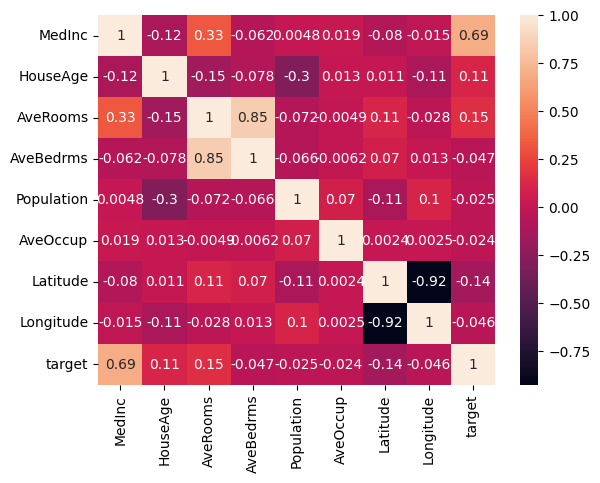

In [130]:
sns.heatmap(df.corr(), annot=True)

In [131]:
X = df.drop(["target", "Longitude", "AveBedrms"], axis=1)

In [132]:
# Разделим на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Добавим признак-смещение (bias)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [133]:
type(y_train)

numpy.ndarray

In [134]:
def predict(X, weights):
    """
    Расчёт предсказания модели
    """
    return X @ weights

def mse_loss(y_true, y_pred):
    """
    Расчёт значения функции ошибки MSE
    """
    return np.mean((y_true - y_pred) ** 2)

In [135]:
def plot_history(losses):
    """
    Визуализация графика сходимости
    (значение loss в зависимости от номера итерации)
    """
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("MSE Loss")
    plt.title("График сходимости градиентного спуска")
    plt.grid(True)
    plt.show()

In [136]:
def regression_metrics(y_true, y_pred):
    """
    Вычисляет метрики качества линейной регрессии.

    Parameters
    ----------
    y_true : array-like
        Реальные значения (таргет).
    y_pred : array-like
        Предсказанные значения.

    Returns
    -------
    dict
        Словарь с метриками: MSE, RMSE, MAE, MAPE, MaxError, R^2.
    """

    # MSE
    mse = mean_squared_error(y_true, y_pred)

    # RMSE
    rmse = np.sqrt(mse)

    # MAE
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE (может вернуть inf, если y_true содержит нули)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred)
    except:
        mape = np.nan

    # MaxError
    max_err = max_error(y_true, y_pred)

    # R^2
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "MaxError": max_err,
        "R^2": r2
    }

### Классический градиентный спуск.

Это мы уже знаем:)

*Базовая формула:*

$w_{k+1} = w_k - \eta \cdot \nabla_w L(w_k)$

In [137]:
def gradient_descent(
    X, y, lr=0.1, n_iter=1000, calc_loss=True, print_loss=True
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features) # начальное приближение
    losses = []

    for i in range(n_iter):
        # предсказание
        y_pred = predict(X, weights)

        # градиент
        error = y_pred - y
        # Чему равен градиент?
        grad = (2 / n_samples) * X.T @ error

        # обновление весов
        # Как мы обновляем веса?
        weights = weights - lr * grad

        # расчёт и сохранение ошибки
        if calc_loss:
            loss = mse_loss(y, y_pred)
            losses.append(loss)

            # промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

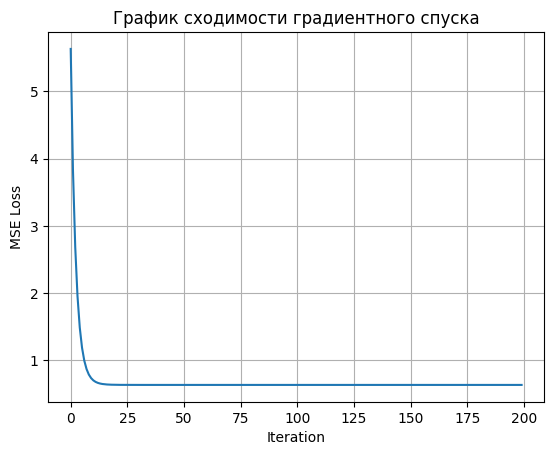

[ 2.07194694  0.83610282  0.22105212 -0.05036069  0.02119718 -0.04873706
 -0.09443353]


In [138]:
weights, losses = gradient_descent(
    X_train, y_train, lr=0.1, n_iter=200, calc_loss=True, print_loss=False
)
plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания на train и test
p_gd_train = predict(X_train, weights)
p_gd_test = predict(X_test, weights)

In [139]:
# классический GD
display(regression_metrics(y_train, p_gd_train))
print()
display(regression_metrics(y_test, p_gd_test))

{'MSE': 0.6356419199481499,
 'RMSE': np.float64(0.7972715471833608),
 'MAE': 0.5935766975314113,
 'MAPE': 0.3619529127643181,
 'MaxError': 6.77951849997126,
 'R^2': 0.5244970973178325}

{'MSE': 0.6473676847425691,
 'RMSE': np.float64(0.8045916260703744),
 'MAE': 0.5982706370703402,
 'MAPE': 0.3684900124084238,
 'MaxError': 4.434678122263657,
 'R^2': 0.5059804263462854}

### Стохастический градиентный спуск.

Это также вспоминаем:)

*Базовая формула:*

$w_{k+1} = w_k - \eta \cdot \nabla_w L\big(w_k; x_i, y_i\big)$

In [140]:
def stochastic_gradient_descent(
    X, y, lr=0.1, n_iter=1000, calc_loss=True, print_loss=False
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses = []

    for i in range(n_iter):
        # случайный индекс примера
        idx = np.random.randint(0, n_samples)
        x_i = X[idx]
        y_i = y[idx]

        # предсказание
        y_pred = x_i @ weights

        # градиент (по одному примеру)
        error = y_pred - y_i
        grad = 2 * x_i * error

        # обновление весов
        weights -= lr * grad

        # для отслеживания динамики считаем полный лосс
        if calc_loss:
            y_full_pred = predict(X, weights)
            loss = mse_loss(y, y_full_pred)
            losses.append(loss)

            # промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

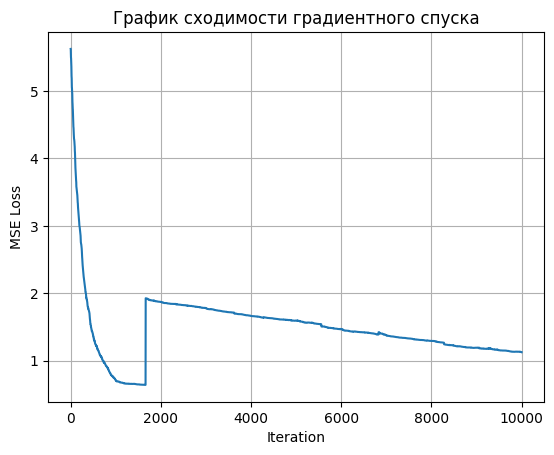

[ 2.09975486  0.82309016  0.21180173 -0.03050173 -0.01527082  0.64762696
 -0.02233269]


In [141]:
weights, losses = stochastic_gradient_descent(
    X_train, y_train, lr=0.001, n_iter=10000, calc_loss=True, print_loss=False
)
plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания на train и test
p_sgd_train = predict(X_train, weights)
p_sgd_test = predict(X_test, weights)

In [142]:
# стохастический GD
display(regression_metrics(y_train, p_sgd_train))
print()
display(regression_metrics(y_test, p_sgd_test))

{'MSE': 1.1254453744974746,
 'RMSE': np.float64(1.0608701025561398),
 'MAE': 0.625038421801918,
 'MAPE': 0.39296347297407863,
 'MaxError': 73.03456947259963,
 'R^2': 0.15809117430860875}

{'MSE': 0.6877876254547799,
 'RMSE': np.float64(0.8293296241270897),
 'MAE': 0.6207892738670551,
 'MAPE': 0.3921677498960536,
 'MaxError': 4.7088693928141625,
 'R^2': 0.47513513958209463}

## 🟢 2. Рассмотрим более продвинутые модификации: AdaGrad и Adam

### AdaGrad

**AdaGrad (Adaptive Gradient)** — метод градиентного спуска с адаптивным шагом обучения  
для каждого параметра.

### Идея
- Каждый параметр получает **свой learning rate**
- Параметры, по которым градиенты большие и частые => шаг уменьшается
- Параметры с редкими обновлениями => шаг остаётся большим  
  (полезно для разреженных признаков)

### Обозначения
- $g_k = \nabla_w L(w_k; x_i, y_i) $ — градиент на шаге $k$
- $ G_k $ — накопленная сумма квадратов градиентов
- $ \eta $ — базовый шаг обучения
- $ \epsilon $ — маленькая константа для численной устойчивости
- $ \odot $ — покомпонентное умножение

### Формулы
$$
G_k = G_{k-1} + g_k \odot g_k
$$

$$
w_{k+1} = w_k - \frac{\eta}{\sqrt{G_k} + \epsilon} \odot g_k
$$

### Особенности
- learning rate **монотонно убывает**
- хорошо работает для NLP и разреженных данных
- может **слишком рано "затормозить" обучение**

### Недостаток
- из-за накопления $G_k$ шаг обучения может стать слишком маленьким  
  => модель перестаёт учиться

Поэтому на практике чаще используют модификации AdaGrad - **RMSProp** и **Adam**.


In [143]:
def adagrad(
    X, y, lr=0.5, n_iter=1000, epsilon=1e-8, calc_loss=True, print_loss=False
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    G = np.zeros(n_features)  # накопление квадратов градиентов
    losses = []

    for i in range(n_iter):
        # полная предсказательная ошибка
        y_pred = predict(X, weights)
        error = y_pred - y
        grad = (2 / n_samples) * X.T @ error

        # обновление накопленной суммы квадратов градиентов
        G += grad ** 2

        # масштабирование градиента
        adjusted_grad = grad / (np.sqrt(G) + epsilon)
        weights -= lr * adjusted_grad

        # лосс
        if calc_loss:
            loss = mse_loss(y, y_pred)
            losses.append(loss)

            # промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

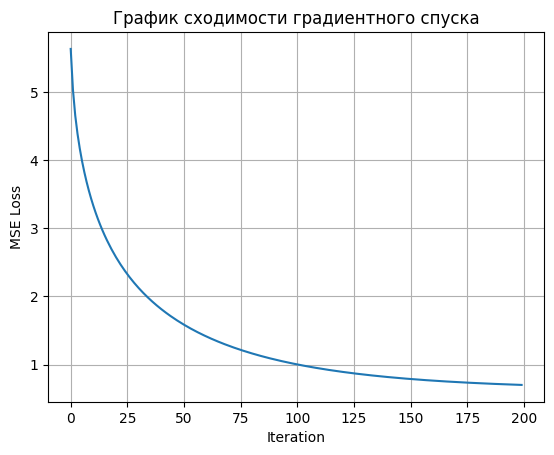

[ 1.8146469   0.83598003  0.22104398 -0.05031511  0.02119681 -0.04873375
 -0.0944492 ]


In [144]:
weights, losses = adagrad(
    X_train, y_train, lr=0.1, n_iter=200
)

plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания на train и test
p_ada_train = predict(X_train, weights)
p_ada_test = predict(X_test, weights)

In [145]:
# AdaGrad
display(regression_metrics(y_train, p_ada_train))
print()
display(regression_metrics(y_test, p_ada_test))

{'MSE': 0.7018452425669439,
 'RMSE': np.float64(0.8377620441192976),
 'MAE': 0.5879719877538842,
 'MAPE': 0.3055738240009148,
 'MaxError': 7.034109714527536,
 'R^2': 0.47497255986283204}

{'MSE': 0.7129689517836696,
 'RMSE': np.float64(0.844374888176851),
 'MAE': 0.5898308286589161,
 'MAPE': 0.3099172119939072,
 'MaxError': 4.691705144555543,
 'R^2': 0.4559187523724364}

### Adam

**Adam (Adaptive Moment Estimation)** — адаптивный метод оптимизации, который хранит и использует статистику прошлых градиентов для более стабильного и быстрого обучения.

### Идея метода

На каждом шаге оптимизации Adam:

* учитывает **направление** градиента (первый момент)
* учитывает **масштаб** градиента (второй момент)
* автоматически подстраивает шаг обучения **для каждого параметра отдельно**

### Формулы обновления

Градиент функции потерь по параметрам:

$$
g_k = \nabla_w L(w_k;, x_i, y_i)
$$

Экспоненциальное скользящее среднее градиента (первый момент):

$$
m_k = \beta_1 m_{k-1} + (1 - \beta_1) g_k
$$

Экспоненциальное скользящее среднее квадратов градиента (второй момент):

$$
v_k = \beta_2 v_{k-1} + (1 - \beta_2)(g_k \odot g_k)
$$

### Смещение на первых шагах и его коррекция

Так как $m_k$ и $v_k$ инициализируются нулями, на первых итерациях они занижены. Для этого используется bias-correction:

$$
\hat{m}_k = \frac{m_k}{1 - \beta_1^k}, \quad
\hat{v}_k = \frac{v_k}{1 - \beta_2^k}
$$

### Обновление параметров

$$
w_{k+1} = w_k -
\frac{\eta}{\sqrt{\hat{v}_k} + \epsilon}
\odot
\hat{m}_k
$$

где:
* $\hat{m}_k$ — усреднённое направление движения
* $\hat{v}_k$ — оценка масштаба градиента
* деление на $\sqrt{\hat{v}_k}$ делает шаг **адаптивным**
* $\epsilon$ предотвращает деление на ноль

**Типичные значения гиперпараметров:**

  * $\beta_1 = 0.9$
  * $\beta_2 = 0.999$
  * $\epsilon = 10^{-8}$

> PS: что делает моментум? Он добавляет "инерцию" к обновлениям весов - градиенты усредняются во времени.

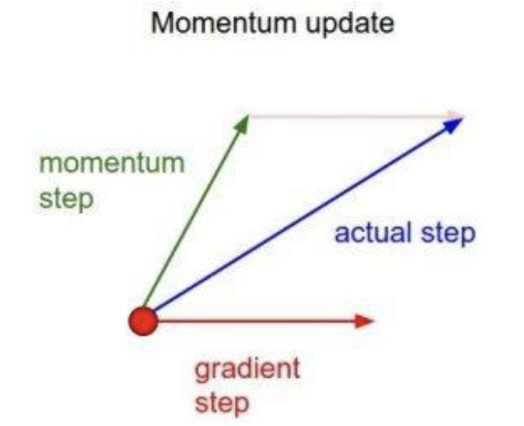

> Это сглаживает траекторию обучения, ускоряет движение в пологих направлениях и помогает выйти из седловых точек.

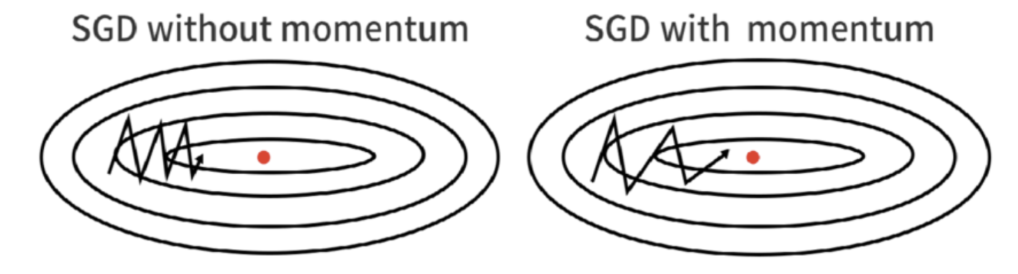

In [146]:
def adam(
    X, y, lr=0.01, n_iter=1000, beta1=0.9, beta2=0.999,
    epsilon=1e-8, calc_loss=True, print_loss=True,
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    m = np.zeros(n_features)  # 1-й момент (среднее градиентов)
    v = np.zeros(n_features)  # 2-й момент (среднее квадратов градиентов)
    losses = []

    for i in range(1, n_iter + 1):
        y_pred = predict(X, weights)
        error = y_pred - y
        grad = (2 / n_samples) * X.T @ error

        # обновления моментов
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2

        # bias correction
        m_hat = m / (1 - beta1**i)
        v_hat = v / (1 - beta2**i)

        # обновление весов
        weights -= lr * m_hat / (np.sqrt(v_hat) + epsilon)

        # лосс
        if calc_loss:
            loss = mse_loss(y, y_pred)
            losses.append(loss)

            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

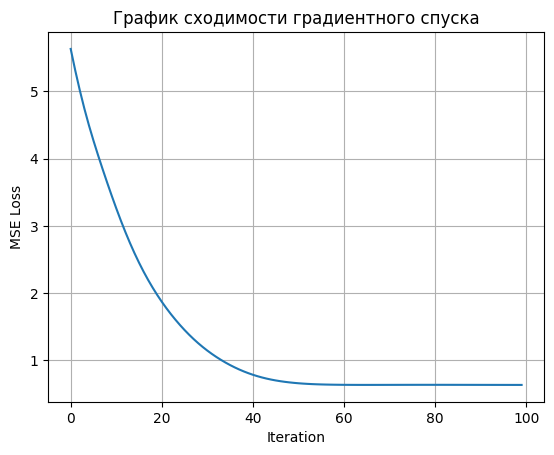

[ 2.08720957  0.83357615  0.22088461 -0.04817688  0.02094772 -0.04864672
 -0.09553682]


In [147]:
weights, losses = adam(
    X_train, y_train, lr=0.05, n_iter=100,
    calc_loss=True, print_loss=False,
)

plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания на train и test
p_adam_train = predict(X_train, weights)
p_adam_test = predict(X_test, weights)

In [148]:
# Adam
display(regression_metrics(y_train, p_adam_train))
print()
display(regression_metrics(y_test, p_adam_test))

{'MSE': 0.6358826728021916,
 'RMSE': np.float64(0.7974225183691463),
 'MAE': 0.596570287728555,
 'MAPE': 0.36717864080605317,
 'MaxError': 6.638195257926391,
 'R^2': 0.5243169979925155}

{'MSE': 0.6475615410878719,
 'RMSE': np.float64(0.804712085834351),
 'MAE': 0.6014591565807627,
 'MAPE': 0.3739033025633075,
 'MaxError': 4.411805980238562,
 'R^2': 0.5058324905884253}

## 🟢 3. Добавим раннюю остановку

Использование **ранней остановки** помогает избежать **переобучения**:
мы прекращаем обучение, когда модель перестаёт улучшать метрику на валидации.

Это позволяет не только сохранять модель с **лучшей обобщающей способностью**, но и экономить время на обучении - что может быть критически важно при работе с тяжелыми нейросетями.


Рассмотрим вариацию SGD с возможностью ранней остановки. Но лосс придётся считать чаще:)

In [149]:
def stochastic_gradient_descent_es(
    X, y, lr=0.1, n_iter=1000, tol=1e-6, patience=10
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses = []

    best_loss = float('inf')
    no_improve_count = 0

    for i in range(n_iter):
        # случайный индекс примера
        idx = np.random.randint(0, n_samples)
        x_i = X[idx]
        y_i = y[idx]

        # предсказание
        y_pred = x_i @ weights

        # градиент (по одному примеру)
        error = y_pred - y_i
        grad = 2 * x_i * error

        # обновление весов
        weights -= lr * grad

        # считаем полный лосс
        y_full_pred = predict(X, weights)
        loss = mse_loss(y, y_full_pred)
        losses.append(loss)

        # проверка на раннюю остановку
        if best_loss - loss > tol:
            best_loss = loss
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print(f"Early stopping in {i} iter.")
            break

    return weights, losses

Early stopping in 144 iter.


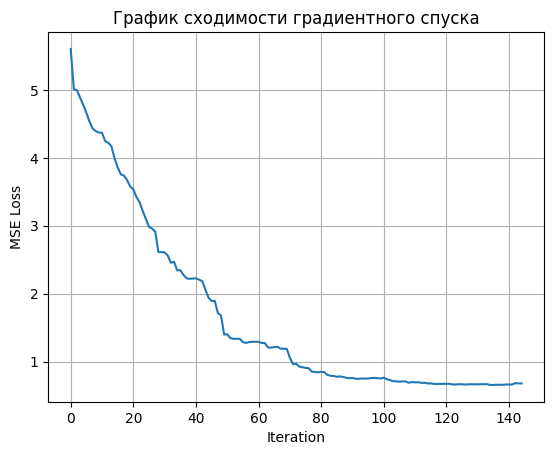

Test MSE: 0.6846


In [150]:
weights, losses = stochastic_gradient_descent_es(
    X_train, y_train, lr=0.01, n_iter=1000,
)

plot_history(losses)

y_test_pred = predict(X_test, weights)
test_loss = mse_loss(y_test, y_test_pred)
print(f"Test MSE: {test_loss:.4f}")